In [12]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # or "." depending on location

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report


from src.pipeline import build_pipeline

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
df.head()

x= df.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
y= df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

categorical_cols = ["Sex", "Embarked"]
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

pipelines = {
    "RandomForest":        build_pipeline(RandomForestClassifier(random_state=42)),
    "XGBoost":             build_pipeline(XGBClassifier(eval_metric='logloss', random_state=42)),
    "LightGBM":            build_pipeline(LGBMClassifier(random_state=42, verbose=-1)),
    "LogisticRegression":  build_pipeline(LogisticRegression(max_iter=1000)),
    "DecisionTree":        build_pipeline(DecisionTreeClassifier(random_state=42)),
}
print("Pipelines ready:", list(pipelines.keys()))

baseline_results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    baseline_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False)
print("\n Baseline Model Comparison:")
print(baseline_df.to_string(index=False))

Train size: (712, 7) | Test size: (179, 7)
Pipelines ready: ['RandomForest', 'XGBoost', 'LightGBM', 'LogisticRegression', 'DecisionTree']


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Baseline Model Comparison:
             Model  Accuracy  F1 Score
          LightGBM    0.8268    0.7891
      RandomForest    0.8212    0.7746
           XGBoost    0.8101    0.7671
LogisticRegression    0.8101    0.7639
      DecisionTree    0.7933    0.7517


In [14]:
model = LGBMClassifier(random_state=42)

pipeline = build_pipeline(model)

pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
preprocessor = pipeline.named_steps["preprocessing"]  
model = pipeline.named_steps["model"]

X_processed = preprocessor.transform(x)

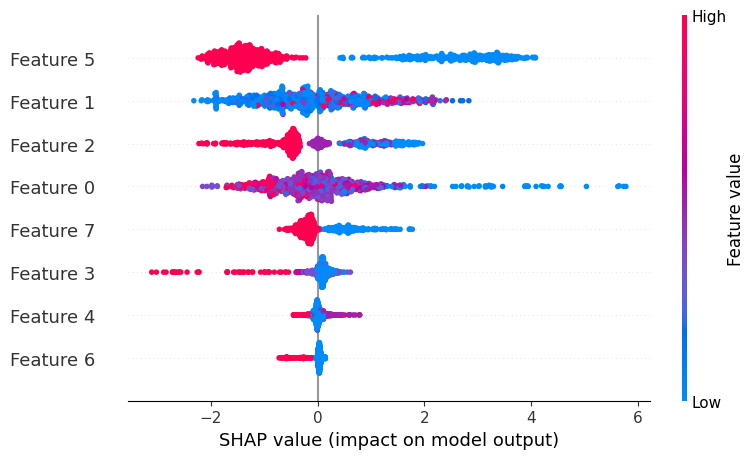

In [24]:
explainer = shap.Explainer(model)
shap_values = explainer(X_processed)

shap.summary_plot(shap_values, X_processed)

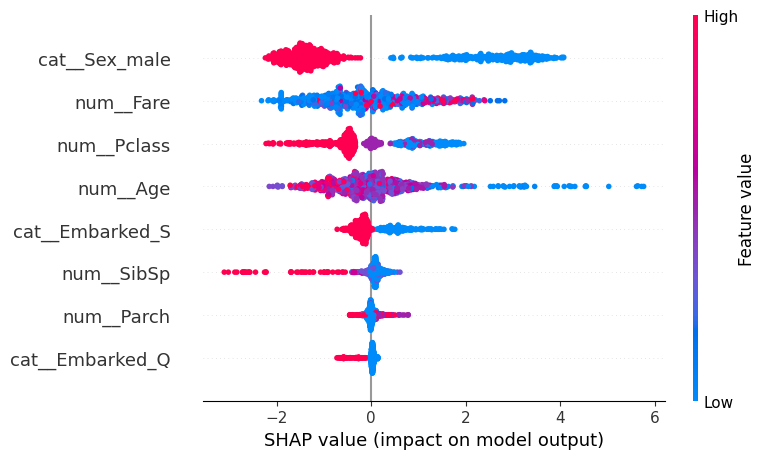

The SHAP summary plot shows which features most influence survival prediction.
Features like Sex, Fare, and Pclass have the highest impact.
 - Being female strongly increases survival probability
 - Higher fare (wealthier passengers) increases survival chances
 - Lower Pclass (1st class) increases survival
Overall, the model captures real-world patterns from the Titanic disaster.


In [27]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values, X_processed, feature_names=feature_names)

print("The SHAP summary plot shows which features most influence survival prediction.\nFeatures like Sex, Fare, and Pclass have the highest impact.\n - Being female strongly increases survival probability\n - Higher fare (wealthier passengers) increases survival chances\n - Lower Pclass (1st class) increases survival\nOverall, the model captures real-world patterns from the Titanic disaster.")

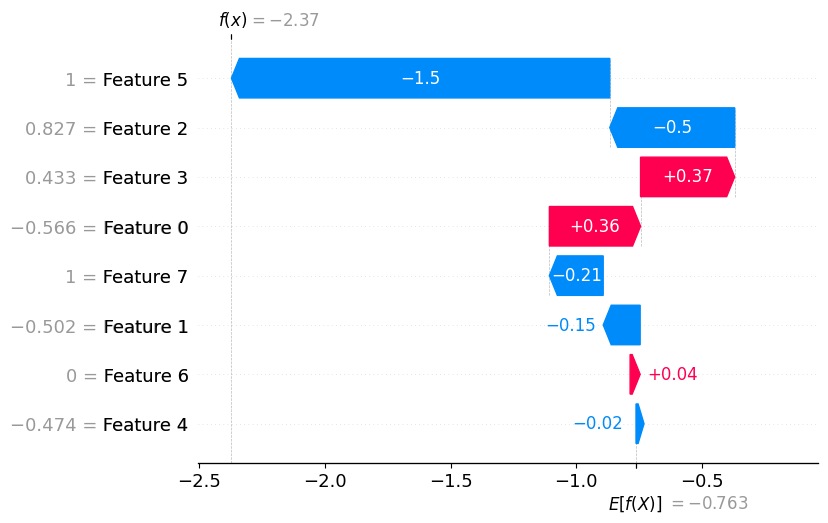

In [ ]:
#for random 1 passenger
i = 0  # first passenger

shap.plots.waterfall(shap_values[i])

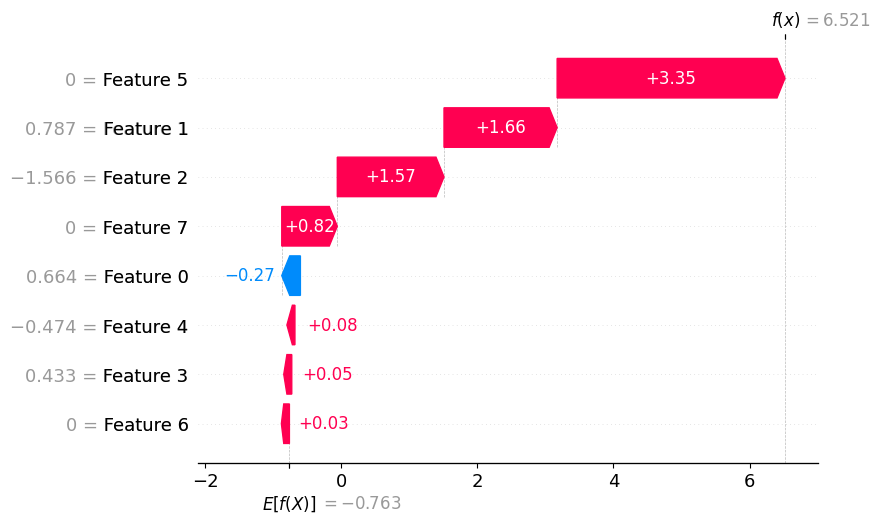

The waterfall plot explains a single prediction.
It shows how each feature contributes to pushing the prediction toward “survived” or “did not survive.”
For this passenger:
 - Positive factors (e.g., female, high fare) increased survival probability
 - Negative factors (e.g., male, low class) decreased it
The final prediction is the sum of all feature contributions.


In [30]:
#for random passengers who Survived
i = y[y == 1].index[0]
shap.plots.waterfall(shap_values[i])

print("The waterfall plot explains a single prediction.\nIt shows how each feature contributes to pushing the prediction toward “survived” or “did not survive.”\nFor this passenger:\n - Positive factors (e.g., female, high fare) increased survival probability\n - Negative factors (e.g., male, low class) decreased it\nThe final prediction is the sum of all feature contributions.")